In [1]:
# ============================================================
# 0. IMPORT LIBRARIES & CONFIG
# ============================================================

import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from lifetimes import BetaGeoFitter, GammaGammaFitter

from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    roc_auc_score,
    average_precision_score
)

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIG
# ============================================================

LOCAL_DATA_DIR = Path(r"E:\marketing for DS\marketing-driven-data-unlock\data\raw")
RELATIVE_DATA_DIR = Path("data/raw")
SANDBOX_DATA_DIR = Path("/mnt/data")

REQUIRED_FILES = [
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_sellers_dataset.csv"
]

def find_data_dir(candidate_dirs, required_files):
    for p in candidate_dirs:
        if p.exists() and all((p / f).exists() for f in required_files):
            return p
    raise FileNotFoundError(
        "Không tìm thấy thư mục chứa đủ 3 file Olist: "
        + ", ".join(required_files)
    )

DATA_DIR = find_data_dir(
    candidate_dirs=[LOCAL_DATA_DIR, RELATIVE_DATA_DIR, SANDBOX_DATA_DIR, Path(".")],
    required_files=REQUIRED_FILES
)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ORDERS_PATH = DATA_DIR / "olist_orders_dataset.csv"
ITEMS_PATH = DATA_DIR / "olist_order_items_dataset.csv"
SELLERS_PATH = DATA_DIR / "olist_sellers_dataset.csv"

COMMISSION_RATE = 0.15
HORIZONS = [30, 60, 90]

ANALYSIS_START = pd.Timestamp("2017-01-01")

# Sửa lỗi logic: lấy hết ngày 2018-04-30, không chỉ lấy 00:00:00
CALIBRATION_END = pd.Timestamp("2018-04-30 23:59:59")

MAX_HOLDOUT_END = CALIBRATION_END + pd.Timedelta(days=max(HORIZONS))

print("Data dir:", DATA_DIR)
print("Output dir:", OUTPUT_DIR)
print("Calibration end:", CALIBRATION_END)
print("Max holdout end:", MAX_HOLDOUT_END)
print("Commission rate:", COMMISSION_RATE)

Data dir: E:\marketing for DS\marketing-driven-data-unlock\data\raw
Output dir: outputs
Calibration end: 2018-04-30 23:59:59
Max holdout end: 2018-07-29 23:59:59
Commission rate: 0.15


In [2]:
# ============================================================
# 2. LOAD RAW DATA
# ============================================================

orders = pd.read_csv(
    ORDERS_PATH,
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

items = pd.read_csv(
    ITEMS_PATH,
    parse_dates=["shipping_limit_date"]
)

sellers = pd.read_csv(SELLERS_PATH)

print("orders:", orders.shape)
print("items:", items.shape)
print("sellers:", sellers.shape)

orders: (99441, 8)
items: (112650, 7)
sellers: (3095, 4)


In [3]:
# ============================================================
# 3. CLEAN & JOIN DATA
# ============================================================

tx = (
    items
    .merge(orders, on="order_id", how="left")
    .merge(sellers, on="seller_id", how="left")
)

tx = tx[
    (tx["order_status"] == "delivered") &
    (tx["order_purchase_timestamp"].notna()) &
    (tx["seller_id"].notna()) &
    (tx["order_id"].notna()) &
    (tx["price"].notna()) &
    (tx["price"] > 0)
].copy()

tx["transaction_date"] = tx["order_purchase_timestamp"]
tx["gmv"] = tx["price"].astype(float)

tx = tx[
    (tx["transaction_date"] >= ANALYSIS_START) &
    (tx["transaction_date"] <= MAX_HOLDOUT_END)
].copy()

print("Clean item-level transactions:", tx.shape)
print("Date range:", tx["transaction_date"].min(), "→", tx["transaction_date"].max())
print("Unique sellers:", tx["seller_id"].nunique())

Clean item-level transactions: (102063, 19)
Date range: 2017-01-05 11:56:06 → 2018-07-29 23:52:17
Unique sellers: 2772


In [4]:
# ============================================================
# 4. BUILD SELLER-ORDER TRANSACTION TABLE
# ============================================================

seller_order_tx = (
    tx
    .groupby(["seller_id", "order_id"], as_index=False)
    .agg(
        transaction_date=("transaction_date", "min"),
        gmv=("gmv", "sum"),
        freight_value=("freight_value", "sum"),
        n_items=("order_item_id", "count"),
        seller_state=("seller_state", "first"),
        seller_city=("seller_city", "first")
    )
    .sort_values(["seller_id", "transaction_date"])
)

print("Seller-order transaction table:", seller_order_tx.shape)
print("Date range:", seller_order_tx["transaction_date"].min(), "→", seller_order_tx["transaction_date"].max())
print("Unique sellers:", seller_order_tx["seller_id"].nunique())

Seller-order transaction table: (90481, 8)
Date range: 2017-01-05 11:56:06 → 2018-07-29 23:52:17
Unique sellers: 2772


In [5]:
# ============================================================
# 6. SPLIT CALIBRATION / HOLDOUT
# ============================================================

cal_tx = seller_order_tx[
    seller_order_tx["transaction_date"] <= CALIBRATION_END
].copy()

holdout_tx = seller_order_tx[
    (seller_order_tx["transaction_date"] > CALIBRATION_END) &
    (seller_order_tx["transaction_date"] <= MAX_HOLDOUT_END)
].copy()

print("Calibration transactions:", cal_tx.shape)
print("Holdout transactions:", holdout_tx.shape)

print("Calibration date range:", cal_tx["transaction_date"].min(), "→", cal_tx["transaction_date"].max())
print("Holdout date range:", holdout_tx["transaction_date"].min(), "→", holdout_tx["transaction_date"].max())

Calibration transactions: (71743, 8)
Holdout transactions: (18738, 8)
Calibration date range: 2017-01-05 11:56:06 → 2018-04-30 23:47:26
Holdout date range: 2018-05-01 00:02:11 → 2018-07-29 23:52:17


In [6]:
# ============================================================
# 7. BUILD CUSTOM BG/NBD SUMMARY
# ============================================================

def build_btyd_summary(
    transactions,
    calibration_end,
    seller_col="seller_id",
    order_col="order_id",
    date_col="transaction_date",
    monetary_col="gmv"
):
    """
    Build seller-level R-F-T summary for BG/NBD and Gamma-Gamma.
    Uses transaction-level seller-order data.
    """
    df = transactions[transactions[date_col] <= calibration_end].copy()
    df = df.sort_values([seller_col, date_col, order_col])
    
    # Rank transactions per seller
    df["txn_rank"] = df.groupby(seller_col).cumcount() + 1
    
    base = (
        df
        .groupby(seller_col)
        .agg(
            total_orders_cal=(order_col, "nunique"),
            total_gmv_cal=(monetary_col, "sum"),
            historical_aov_cal=(monetary_col, "mean"),
            first_order_date=(date_col, "min"),
            last_order_date=(date_col, "max")
        )
    )
    
    # BG/NBD frequency = repeat transactions
    base["frequency"] = (base["total_orders_cal"] - 1).clip(lower=0)
    
    # Time variables in days
    base["recency"] = (
        base["last_order_date"] - base["first_order_date"]
    ).dt.total_seconds() / 86400
    
    base["T"] = (
        pd.Timestamp(calibration_end) - base["first_order_date"]
    ).dt.total_seconds() / 86400
    
    # T must be positive
    base["T"] = base["T"].clip(lower=1e-3)
    
    # monetary_value for Gamma-Gamma = average value of repeat transactions
    repeat_tx = df[df["txn_rank"] > 1].copy()
    
    repeat_monetary = (
        repeat_tx
        .groupby(seller_col)[monetary_col]
        .mean()
        .rename("monetary_value")
    )
    
    base = base.join(repeat_monetary, how="left")
    base["monetary_value"] = base["monetary_value"].fillna(0)
    
    # Keep useful columns
    summary = base[
        [
            "frequency",
            "recency",
            "T",
            "monetary_value",
            "total_orders_cal",
            "total_gmv_cal",
            "historical_aov_cal",
            "first_order_date",
            "last_order_date"
        ]
    ].copy()
    
    return summary


summary = build_btyd_summary(
    transactions=cal_tx,
    calibration_end=CALIBRATION_END
)

print("BG/NBD summary:", summary.shape)
display(summary.head())

BG/NBD summary: (2248, 9)


,frequency,recency,T,monetary_value,total_orders_cal,total_gmv_cal,historical_aov_cal,first_order_date,last_order_date
seller_id,,,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,2,21.416308,216.071458,895.000000,3,2685.00,895.000000,2017-09-26 22:17:05,2017-10-18 08:16:34
001cca7ae9ae17fb1caed9dfb1094831,191,447.554861,450.204109,125.739424,192,24116.13,125.604844,2017-02-04 19:06:04,2018-04-28 08:25:04
002100f778ceb8431b7a1020ff7ab48f,49,210.498519,228.957963,24.626531,50,1216.60,24.332000,2017-09-14 01:00:31,2018-04-12 12:58:23
003554e2dce176b5555353e4f3555ac8,0,0.000000,136.713588,0.000000,1,120.00,120.000000,2017-12-15 06:52:25,2017-12-15 06:52:25
004c9cd9d87a3c30c522c48c4fc07416,153,444.125498,458.559317,124.838170,154,19220.23,124.806688,2017-01-27 10:34:34,2018-04-16 13:35:17


In [7]:
# ============================================================
# 8. ADD ACTUAL HOLDOUT TARGETS FOR EACH HORIZON
# ============================================================

def add_actuals_by_horizon(
    score_df,
    transactions,
    calibration_end,
    horizons,
    seller_col="seller_id",
    order_col="order_id",
    date_col="transaction_date",
    monetary_col="gmv"
):
    out = score_df.copy()
    cal = pd.Timestamp(calibration_end)
    
    for h in horizons:
        end_date = cal + pd.Timedelta(days=int(h))
        
        h_tx = transactions[
            (transactions[date_col] > cal) &
            (transactions[date_col] <= end_date)
        ].copy()
        
        actual = (
            h_tx
            .groupby(seller_col)
            .agg(
                **{
                    f"actual_orders_{h}d": (order_col, "nunique"),
                    f"actual_gmv_{h}d": (monetary_col, "sum")
                }
            )
        )
        
        out = out.join(actual, how="left")
        
        out[f"actual_orders_{h}d"] = out[f"actual_orders_{h}d"].fillna(0)
        out[f"actual_gmv_{h}d"] = out[f"actual_gmv_{h}d"].fillna(0)
        out[f"actual_active_{h}d"] = (
            out[f"actual_orders_{h}d"] > 0
        ).astype(int)
    
    return out


score = add_actuals_by_horizon(
    score_df=summary,
    transactions=seller_order_tx,
    calibration_end=CALIBRATION_END,
    horizons=HORIZONS
)

for h in HORIZONS:
    print(
        f"Horizon {h}d | Existing-seller active rate:",
        round(score[f"actual_active_{h}d"].mean(), 4),
        "| Existing-seller actual orders:",
        int(score[f"actual_orders_{h}d"].sum()),
        "| Existing-seller actual GMV:",
        round(score[f"actual_gmv_{h}d"].sum(), 2)
    )

Horizon 30d | Existing-seller active rate: 0.4115 | Existing-seller actual orders: 6367 | Existing-seller actual GMV: 894056.48
Horizon 60d | Existing-seller active rate: 0.4929 | Existing-seller actual orders: 11751 | Existing-seller actual GMV: 1637110.34
Horizon 90d | Existing-seller active rate: 0.5271 | Existing-seller actual orders: 16406 | Existing-seller actual GMV: 2261429.39


## Fit BG/NBD

In [8]:
# ============================================================
# 9. FIT BG/NBD MODEL
# ============================================================
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(
    frequency=score["frequency"],
    recency=score["recency"],
    T=score["T"]
)
print(bgf.summary)

           coef  se(coef)  lower 95% bound  upper 95% bound
r      0.445486  0.013303         0.419412         0.471561
alpha  3.365220  0.149995         3.071230         3.659210
a      0.144359  0.009843         0.125066         0.163652
b      2.291989  0.240068         1.821455         2.762523


In [9]:
# ============================================================
# 10. PREDICT FUTURE ORDERS WITH BG/NBD
# ============================================================

score["prob_alive"] = bgf.conditional_probability_alive(
    frequency=score["frequency"],
    recency=score["recency"],
    T=score["T"]
)

for h in HORIZONS:
    score[f"expected_orders_{h}d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
        t=h,
        frequency=score["frequency"],
        recency=score["recency"],
        T=score["T"]
    )

    # Ranking score for future seller activity
    score[f"activity_score_{h}d"] = score[f"expected_orders_{h}d"]

    # Poisson-style approximation, not exact BG/NBD probability
    score[f"p_purchase_approx_{h}d"] = 1 - np.exp(-score[f"expected_orders_{h}d"])

display(
    score[
        [
            "frequency", "recency", "T",
            "prob_alive",
            "expected_orders_30d", "activity_score_30d", "p_purchase_approx_30d",
            "expected_orders_60d", "activity_score_60d", "p_purchase_approx_60d",
            "expected_orders_90d", "activity_score_90d", "p_purchase_approx_90d"
        ]
    ].head()
)


,frequency,recency,T,prob_alive,expected_orders_30d,activity_score_30d,p_purchase_approx_30d,expected_orders_60d,activity_score_60d,p_purchase_approx_60d,expected_orders_90d,activity_score_90d,p_purchase_approx_90d
seller_id,,,,,,,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,2,21.416308,216.071458,0.099162,0.032909,0.032909,0.032373,0.065367,0.065367,0.063276,0.097420,0.097420,0.092825
001cca7ae9ae17fb1caed9dfb1094831,191,447.554861,450.204109,0.997701,12.574934,12.574934,0.999997,25.038213,25.038213,1.000000,37.397244,37.397244,1.000000
002100f778ceb8431b7a1020ff7ab48f,49,210.498519,228.957963,0.853171,5.399887,5.399887,0.995483,10.712664,10.712664,0.999978,15.948371,15.948371,1.000000
003554e2dce176b5555353e4f3555ac8,0,0.000000,136.713588,1.000000,0.094579,0.094579,0.090245,0.187662,0.187662,0.171106,0.279443,0.279443,0.243795
004c9cd9d87a3c30c522c48c4fc07416,153,444.125498,458.559317,0.891200,8.840980,8.840980,0.999855,17.604879,17.604879,1.000000,26.296725,26.296725,1.000000


## BG/NBD metrics

In [10]:
# ============================================================
# 11. EVALUATE BG/NBD ACTIVITY MODEL
# ============================================================

def lift_at_top_k(df, score_col, target_col, k=0.10):
    temp = df[[score_col, target_col]].dropna().copy()
    temp = temp.sort_values(score_col, ascending=False)

    n_top = max(1, int(len(temp) * k))
    top = temp.head(n_top)

    base_rate = temp[target_col].mean()
    top_rate = top[target_col].mean()

    if base_rate == 0:
        return np.nan

    return top_rate / base_rate


activity_eval = []

for h in HORIZONS:
    y_true = score[f"actual_active_{h}d"]
    y_score = score[f"activity_score_{h}d"]

    if y_true.nunique() == 2:
        roc_auc = roc_auc_score(y_true, y_score)
        pr_auc = average_precision_score(y_true, y_score)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    lift10 = lift_at_top_k(
        df=score,
        score_col=f"activity_score_{h}d",
        target_col=f"actual_active_{h}d",
        k=0.10
    )

    mae_orders = mean_absolute_error(score[f"actual_orders_{h}d"], score[f"expected_orders_{h}d"])
    medae_orders = median_absolute_error(score[f"actual_orders_{h}d"], score[f"expected_orders_{h}d"])

    total_pred_orders = score[f"expected_orders_{h}d"].sum()
    total_actual_orders = score[f"actual_orders_{h}d"].sum()

    activity_eval.append({
        "horizon": h,
        "active_rate": y_true.mean(),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "lift_top10": lift10,
        "mae_orders": mae_orders,
        "median_ae_orders": medae_orders,
        "total_pred_orders": total_pred_orders,
        "total_actual_orders": total_actual_orders,
        "order_error_pct": (
            (total_pred_orders - total_actual_orders) / total_actual_orders
            if total_actual_orders > 0 else np.nan
        )
    })

activity_eval_df = pd.DataFrame(activity_eval)
display(activity_eval_df)


,horizon,active_rate,roc_auc,pr_auc,lift_top10,mae_orders,median_ae_orders,total_pred_orders,total_actual_orders,order_error_pct
0,30,0.411477,0.901105,0.865397,2.343475,1.897672,0.535946,6476.196718,6367.0,0.017150
1,60,0.492883,0.909553,0.906361,2.001708,3.417715,0.850074,12806.823428,11751.0,0.089850
2,90,0.527135,0.908029,0.915053,1.871640,4.968433,1.249227,19027.972388,16406.0,0.159818


## Fit Gamma-Gamma

In [11]:
# ============================================================
# 12. PREPARE DATA FOR GAMMA-GAMMA
# ============================================================

gg_data = score[
    (score["frequency"] > 0) &
    (score["monetary_value"] > 0)
].copy()

print("Gamma-Gamma training sellers:", gg_data.shape[0])


Gamma-Gamma training sellers: 1833


In [12]:
# ============================================================
# 13. FIT GAMMA-GAMMA MODEL
# ============================================================

ggf = GammaGammaFitter(penalizer_coef=0.001)

ggf.fit(
    frequency=gg_data["frequency"],
    monetary_value=gg_data["monetary_value"]
)

print(ggf.summary)

       coef  se(coef)  lower 95% bound  upper 95% bound
p  8.612164  0.299870         8.024419         9.199908
q  1.097865  0.032549         1.034068         1.161662
v  8.715475  0.313936         8.100161         9.330789


In [13]:
# ============================================================
# 14. PREDICT EXPECTED AVERAGE GMV
# ============================================================

score["gg_expected_avg_gmv"] = np.nan

valid_gg = (
    (score["frequency"] > 0) &
    (score["monetary_value"] > 0)
)

score.loc[valid_gg, "gg_expected_avg_gmv"] = ggf.conditional_expected_average_profit(
    frequency=score.loc[valid_gg, "frequency"],
    monetary_value=score.loc[valid_gg, "monetary_value"]
)

# Fallback:
# Nếu seller không đủ điều kiện Gamma-Gamma, dùng historical AOV.
# Nếu vẫn thiếu, dùng median AOV của toàn bộ seller.
median_aov = score["historical_aov_cal"].median()

score["expected_avg_gmv"] = (
    score["gg_expected_avg_gmv"]
    .fillna(score["historical_aov_cal"])
    .fillna(median_aov)
)

score["expected_avg_gmv"] = score["expected_avg_gmv"].clip(lower=0)

display(
    score[
        [
            "frequency",
            "monetary_value",
            "historical_aov_cal",
            "gg_expected_avg_gmv",
            "expected_avg_gmv"
        ]
    ].head()
)

,frequency,monetary_value,historical_aov_cal,gg_expected_avg_gmv,expected_avg_gmv
seller_id,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,2,895.000000,895.000000,894.276630,894.276630
001cca7ae9ae17fb1caed9dfb1094831,191,125.739424,125.604844,125.777572,125.777572
002100f778ceb8431b7a1020ff7ab48f,49,24.626531,24.332000,24.798646,24.798646
003554e2dce176b5555353e4f3555ac8,0,0.000000,120.000000,NaN,120.000000
004c9cd9d87a3c30c522c48c4fc07416,153,124.838170,124.806688,124.885858,124.885858


In [14]:
# ============================================================
# 15. COMPUTE SELLER HORIZON VALUE FOR EACH HORIZON
# ============================================================

for h in HORIZONS:
    score[f"predicted_gmv_{h}d"] = (
        score[f"expected_orders_{h}d"] *
        score["expected_avg_gmv"]
    )

    # Expected marketplace commission over horizon, not full lifetime CLV
    score[f"expected_commission_{h}d"] = (
        score[f"predicted_gmv_{h}d"] *
        COMMISSION_RATE
    )

    score[f"actual_commission_{h}d"] = (
        score[f"actual_gmv_{h}d"] *
        COMMISSION_RATE
    )

display(
    score[
        [
            "expected_avg_gmv",
            "expected_orders_30d", "expected_commission_30d", "actual_commission_30d",
            "expected_orders_60d", "expected_commission_60d", "actual_commission_60d",
            "expected_orders_90d", "expected_commission_90d", "actual_commission_90d"
        ]
    ].head()
)


,expected_avg_gmv,expected_orders_30d,expected_commission_30d,actual_commission_30d,expected_orders_60d,expected_commission_60d,actual_commission_60d,expected_orders_90d,expected_commission_90d,actual_commission_90d
seller_id,,,,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,894.276630,0.032909,4.414461,0.000,0.065367,8.768389,0.000,0.097420,13.068032,0.000
001cca7ae9ae17fb1caed9dfb1094831,125.777572,12.574934,237.246702,0.000,25.038213,472.386845,36.150,37.397244,705.560188,55.635
002100f778ceb8431b7a1020ff7ab48f,24.798646,5.399887,20.086482,0.000,10.712664,39.848936,0.000,15.948371,59.324701,0.000
003554e2dce176b5555353e4f3555ac8,120.000000,0.094579,1.702429,0.000,0.187662,3.377924,0.000,0.279443,5.029969,0.000
004c9cd9d87a3c30c522c48c4fc07416,124.885858,8.840980,165.616998,52.425,17.604879,329.790066,52.425,26.296725,492.613363,52.425


## Value metrics

In [15]:
# ============================================================
# 16. EVALUATE SELLER VALUE MODEL
# ============================================================

def top_value_capture(df, pred_col, actual_col, k=0.10):
    temp = df[[pred_col, actual_col]].dropna().copy()
    temp = temp.sort_values(pred_col, ascending=False)

    n_top = max(1, int(len(temp) * k))
    top = temp.head(n_top)

    total_actual = temp[actual_col].sum()

    if total_actual == 0:
        return np.nan

    return top[actual_col].sum() / total_actual


value_eval = []

for h in HORIZONS:
    pred = score[f"expected_commission_{h}d"]
    actual = score[f"actual_commission_{h}d"]

    mae = mean_absolute_error(actual, pred)
    medae = median_absolute_error(actual, pred)

    if actual.nunique() > 1 and pred.nunique() > 1:
        spearman_corr = spearmanr(actual, pred).correlation
    else:
        spearman_corr = np.nan

    capture10 = top_value_capture(
        df=score,
        pred_col=f"expected_commission_{h}d",
        actual_col=f"actual_commission_{h}d",
        k=0.10
    )

    total_pred = pred.sum()
    total_actual = actual.sum()

    value_eval.append({
        "horizon": h,
        "mae_commission": mae,
        "median_ae_commission": medae,
        "spearman_rank_corr": spearman_corr,
        "top10_value_capture": capture10,
        "total_predicted_commission": total_pred,
        "total_actual_commission": total_actual,
        "commission_error_pct": (
            (total_pred - total_actual) / total_actual
            if total_actual > 0 else np.nan
        )
    })

value_eval_df = pd.DataFrame(value_eval)
display(value_eval_df)


,horizon,mae_commission,median_ae_commission,spearman_rank_corr,top10_value_capture,total_predicted_commission,total_actual_commission,commission_error_pct
0,30,44.929397,10.224363,0.676113,0.649869,134954.296903,134108.4720,0.006307
1,60,77.356519,17.656557,0.727956,0.646146,266554.125999,245566.5510,0.085466
2,90,111.324751,26.640194,0.739985,0.639479,395678.001414,339214.4085,0.166454


In [16]:
# ============================================================
# 17. VALIDATION METRICS
# ============================================================

def top_value_capture(df, pred_col, actual_col, k=0.10):
    temp = df[[pred_col, actual_col]].dropna().copy()
    temp = temp.sort_values(pred_col, ascending=False)

    n_top = max(1, int(len(temp) * k))
    top = temp.head(n_top)

    total_actual = temp[actual_col].sum()

    if total_actual == 0:
        return np.nan

    return top[actual_col].sum() / total_actual


def lift_at_top_k(df, score_col, target_col, k=0.10):
    temp = df[[score_col, target_col]].dropna().copy()
    temp = temp.sort_values(score_col, ascending=False)

    n_top = max(1, int(len(temp) * k))
    top = temp.head(n_top)

    base_rate = temp[target_col].mean()
    top_rate = top[target_col].mean()

    if base_rate == 0:
        return np.nan

    return top_rate / base_rate


def safe_pct_error(pred, actual):
    if actual == 0:
        return np.nan
    return (pred - actual) / actual


def decile_calibration(df, pred_col, actual_col, n_bins=10):
    temp = df[[pred_col, actual_col]].dropna().copy()

    temp["decile"] = pd.qcut(
        temp[pred_col].rank(method="first"),
        q=n_bins,
        labels=False
    ) + 1

    out = (
        temp
        .groupby("decile")
        .agg(
            n=("decile", "size"),
            avg_pred=(pred_col, "mean"),
            avg_actual=(actual_col, "mean"),
            total_pred=(pred_col, "sum"),
            total_actual=(actual_col, "sum")
        )
        .reset_index()
        .sort_values("decile", ascending=False)
    )

    out["actual_over_pred"] = np.where(
        out["total_pred"] > 0,
        out["total_actual"] / out["total_pred"],
        np.nan
    )

    return out


# ============================================================
# A. BG/NBD ACTIVITY METRICS
# ============================================================

activity_eval = []

for h in HORIZONS:
    y_true = score[f"actual_active_{h}d"]
    y_score = score[f"activity_score_{h}d"]

    if y_true.nunique() == 2:
        roc_auc = roc_auc_score(y_true, y_score)
        pr_auc = average_precision_score(y_true, y_score)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    pred_orders = score[f"expected_orders_{h}d"]
    actual_orders = score[f"actual_orders_{h}d"]

    total_pred_orders = pred_orders.sum()
    total_actual_orders = actual_orders.sum()

    activity_eval.append({
        "horizon": h,
        "active_rate": y_true.mean(),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "lift_top10_active": lift_at_top_k(
            df=score,
            score_col=f"activity_score_{h}d",
            target_col=f"actual_active_{h}d",
            k=0.10
        ),
        "mae_orders": mean_absolute_error(actual_orders, pred_orders),
        "median_ae_orders": median_absolute_error(actual_orders, pred_orders),
        "total_pred_orders": total_pred_orders,
        "total_actual_orders": total_actual_orders,
        "order_error_pct": safe_pct_error(total_pred_orders, total_actual_orders)
    })

activity_eval_df = pd.DataFrame(activity_eval)

print("A. BG/NBD activity metrics")
display(activity_eval_df)


# ============================================================
# B. GAMMA-GAMMA MONETARY METRICS
# ============================================================

monetary_eval = []

for h in HORIZONS:
    # Chỉ đánh giá AOV trên seller có phát sinh order thật trong holdout
    temp = score[score[f"actual_orders_{h}d"] > 0].copy()

    if len(temp) > 0:
        temp[f"actual_avg_gmv_{h}d"] = (
            temp[f"actual_gmv_{h}d"] / temp[f"actual_orders_{h}d"]
        )

        pred_aov = temp["expected_avg_gmv"]
        actual_aov = temp[f"actual_avg_gmv_{h}d"]

        if actual_aov.nunique() > 1 and pred_aov.nunique() > 1:
            spearman_aov = spearmanr(actual_aov, pred_aov).correlation
        else:
            spearman_aov = np.nan

        monetary_eval.append({
            "horizon": h,
            "n_sellers_with_holdout_orders": len(temp),
            "mae_aov": mean_absolute_error(actual_aov, pred_aov),
            "median_ae_aov": median_absolute_error(actual_aov, pred_aov),
            "spearman_aov": spearman_aov,
            "avg_pred_aov": pred_aov.mean(),
            "avg_actual_aov": actual_aov.mean(),
            "aov_error_pct": safe_pct_error(pred_aov.mean(), actual_aov.mean())
        })

monetary_eval_df = pd.DataFrame(monetary_eval)

print("B. Gamma-Gamma monetary metrics")
display(monetary_eval_df)


# ============================================================
# C. COMBINED VALUE METRICS
# ============================================================

value_eval = []

for h in HORIZONS:
    pred = score[f"expected_commission_{h}d"]
    actual = score[f"actual_commission_{h}d"]

    if actual.nunique() > 1 and pred.nunique() > 1:
        spearman_corr = spearmanr(actual, pred).correlation
    else:
        spearman_corr = np.nan

    total_pred = pred.sum()
    total_actual = actual.sum()

    value_eval.append({
        "horizon": h,
        "mae_commission": mean_absolute_error(actual, pred),
        "median_ae_commission": median_absolute_error(actual, pred),
        "spearman_rank_corr": spearman_corr,
        "top10_value_capture": top_value_capture(
            df=score,
            pred_col=f"expected_commission_{h}d",
            actual_col=f"actual_commission_{h}d",
            k=0.10
        ),
        "total_predicted_commission": total_pred,
        "total_actual_commission": total_actual,
        "commission_error_pct": safe_pct_error(total_pred, total_actual)
    })

value_eval_df = pd.DataFrame(value_eval)

print("C. Combined BG/NBD + Gamma-Gamma value metrics")
display(value_eval_df)


# ============================================================
# D. AGGREGATE FORECAST TABLE
# ============================================================

aggregate_eval = []

for h in HORIZONS:
    pred_orders = score[f"expected_orders_{h}d"].sum()
    actual_orders = score[f"actual_orders_{h}d"].sum()

    pred_gmv = score[f"predicted_gmv_{h}d"].sum()
    actual_gmv = score[f"actual_gmv_{h}d"].sum()

    pred_commission = score[f"expected_commission_{h}d"].sum()
    actual_commission = score[f"actual_commission_{h}d"].sum()

    aggregate_eval.append({
        "horizon": h,
        "pred_orders": pred_orders,
        "actual_orders": actual_orders,
        "order_error_pct": safe_pct_error(pred_orders, actual_orders),
        "pred_gmv": pred_gmv,
        "actual_gmv": actual_gmv,
        "gmv_error_pct": safe_pct_error(pred_gmv, actual_gmv),
        "pred_commission": pred_commission,
        "actual_commission": actual_commission,
        "commission_error_pct": safe_pct_error(pred_commission, actual_commission)
    })

aggregate_eval_df = pd.DataFrame(aggregate_eval)

print("D. Aggregate forecast metrics")
display(aggregate_eval_df)


# ============================================================
# E. DECILE & CONDITIONAL TABLES FOR 90D
# ============================================================

H = 90

decile_eval_90d = decile_calibration(
    df=score,
    pred_col=f"expected_commission_{H}d",
    actual_col=f"actual_commission_{H}d",
    n_bins=10
)

print("E1. Decile calibration 90d")
display(decile_eval_90d)


score["frequency_bucket"] = pd.cut(
    score["frequency"],
    bins=[-1, 0, 1, 2, 5, 10, 50, np.inf],
    labels=["0", "1", "2", "3-5", "6-10", "11-50", "50+"]
)

conditional_eval_90d = (
    score
    .groupby("frequency_bucket", observed=False)
    .agg(
        n_sellers=("frequency", "size"),
        avg_pred_orders_90d=("expected_orders_90d", "mean"),
        avg_actual_orders_90d=("actual_orders_90d", "mean"),
        avg_pred_commission_90d=("expected_commission_90d", "mean"),
        avg_actual_commission_90d=("actual_commission_90d", "mean")
    )
    .reset_index()
)

print("E2. Conditional expectation by frequency bucket 90d")
display(conditional_eval_90d)

A. BG/NBD activity metrics


,horizon,active_rate,roc_auc,pr_auc,lift_top10_active,mae_orders,median_ae_orders,total_pred_orders,total_actual_orders,order_error_pct
0,30,0.411477,0.901105,0.865397,2.343475,1.897672,0.535946,6476.196718,6367.0,0.017150
1,60,0.492883,0.909553,0.906361,2.001708,3.417715,0.850074,12806.823428,11751.0,0.089850
2,90,0.527135,0.908029,0.915053,1.871640,4.968433,1.249227,19027.972388,16406.0,0.159818


B. Gamma-Gamma monetary metrics


,horizon,n_sellers_with_holdout_orders,mae_aov,median_ae_aov,spearman_aov,avg_pred_aov,avg_actual_aov,aov_error_pct
0,30,925,75.978164,26.786520,0.744262,172.882025,175.670717,-0.015875
1,60,1108,75.413216,27.836649,0.744659,179.799877,181.403050,-0.008838
2,90,1185,72.049454,27.696675,0.768784,188.523837,188.108503,0.002208


C. Combined BG/NBD + Gamma-Gamma value metrics


...

,horizon,pred_orders,actual_orders,order_error_pct,pred_gmv,actual_gmv,gmv_error_pct,pred_commission,actual_commission,commission_error_pct
0,30,6476.196718,6367.0,0.017150,8.996953e+05,894056.48,0.006307,134954.296903,134108.4720,0.006307
1,60,12806.823428,11751.0,0.089850,1.777028e+06,1637110.34,0.085466,266554.125999,245566.5510,0.085466
2,90,19027.972388,16406.0,0.159818,2.637853e+06,2261429.39,0.166454,395678.001414,339214.4085,0.166454


E1. Decile calibration 90d


,decile,n,avg_pred,avg_actual,total_pred,total_actual,actual_over_pred
9,10,225,1141.522859,964.090567,256842.643200,216920.3775,0.844565
8,9,225,276.395275,212.948693,62188.936858,47913.4560,0.770450
7,8,225,153.676604,129.929633,34577.235904,29234.1675,0.845474
6,7,224,90.878780,83.484522,20356.846800,18700.5330,0.918636
5,6,225,53.099268,52.075040,11947.335381,11716.8840,0.980711
4,5,225,26.355168,37.919667,5929.912892,8531.9250,1.438794
3,4,224,11.192045,11.497480,2507.018060,2575.4355,1.027290
2,3,225,4.357379,6.582073,980.410174,1480.9665,1.510558
1,2,225,1.437927,2.860527,323.533587,643.6185,1.989341
0,1,225,0.107238,6.653533,24.128559,1497.0450,62.044526


E2. Conditional expectation by frequency bucket 90d


,frequency_bucket,n_sellers,avg_pred_orders_90d,avg_actual_orders_90d,avg_pred_commission_90d,avg_actual_commission_90d
0,0,415,0.958460,0.918072,33.570932,20.737822
1,1,224,1.332813,1.450893,44.061276,38.952696
2,2,174,2.077650,1.747126,64.078969,61.170267
3,3-5,300,2.844723,2.643333,88.609112,64.262230
4,6-10,286,3.236793,2.835664,81.041975,79.253392
5,11-50,540,7.880411,7.488889,194.711824,184.503242
6,50+,309,38.626502,31.546926,666.088915,549.068908


## Validation plots

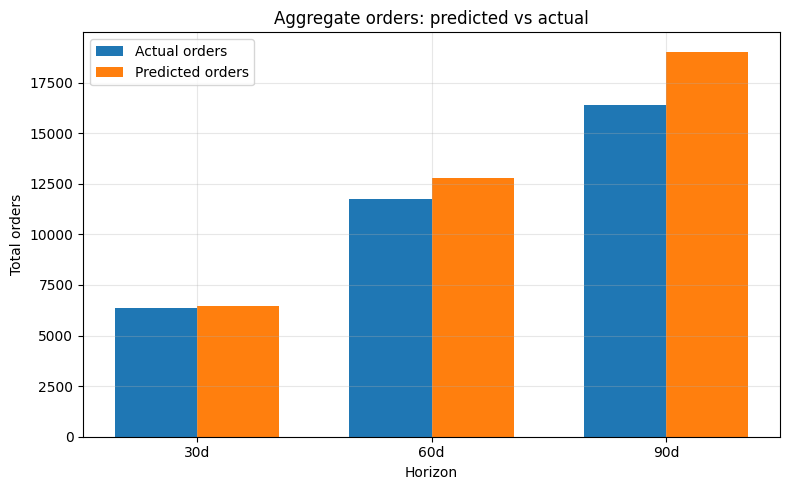

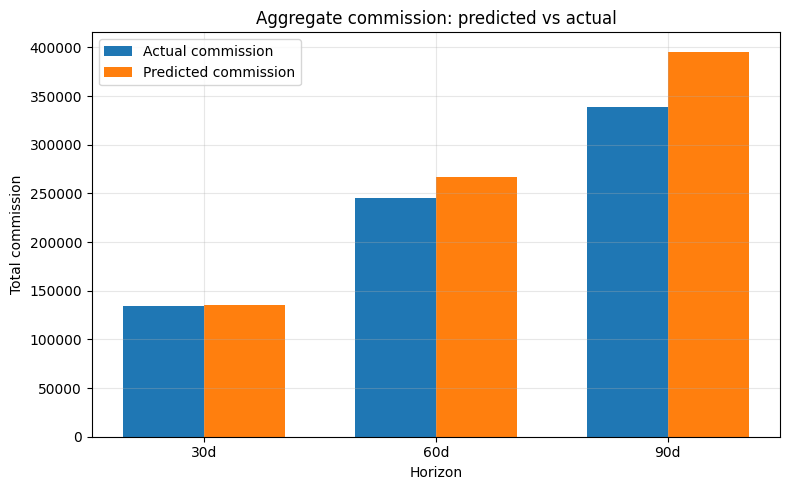

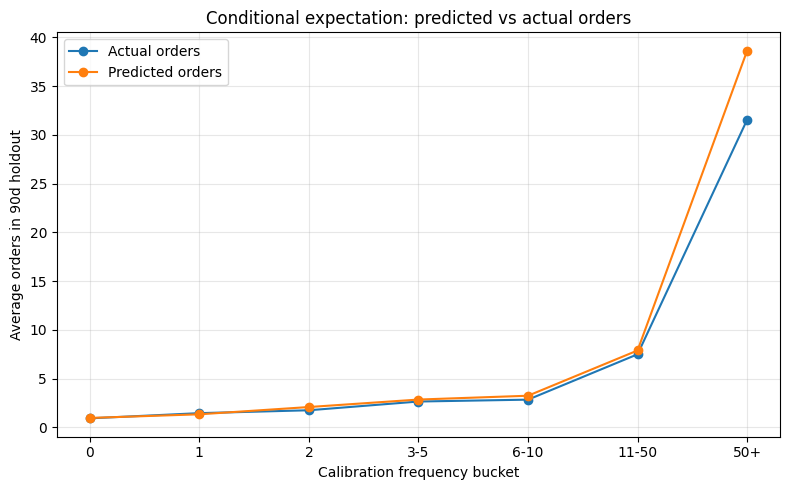

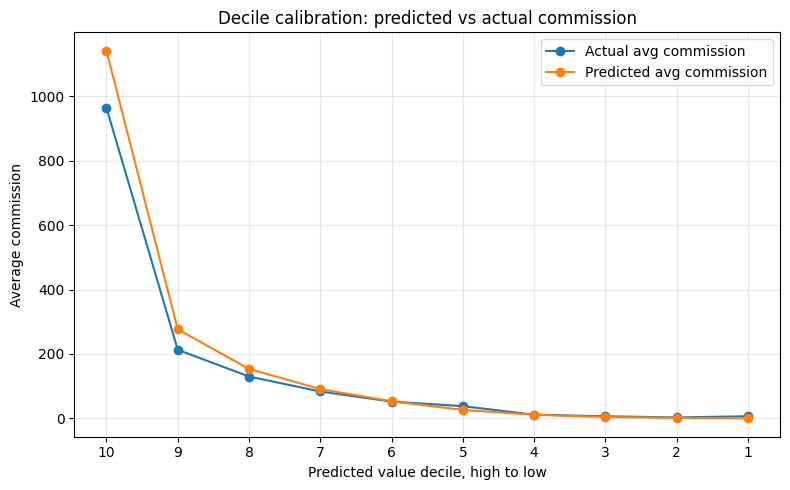

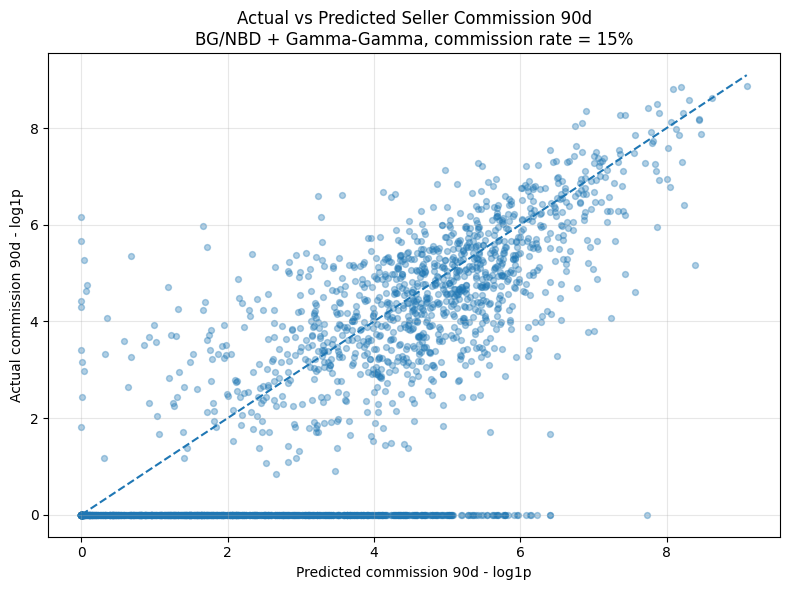

In [20]:
# ============================================================
# 18. VALIDATION PLOTS
# ============================================================

H = 90

# ============================================================
# Plot 1: Aggregate orders predicted vs actual
# ============================================================

plot_agg = aggregate_eval_df.copy()
x = np.arange(len(plot_agg))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    plot_agg["actual_orders"],
    width,
    label="Actual orders"
)

plt.bar(
    x + width / 2,
    plot_agg["pred_orders"],
    width,
    label="Predicted orders"
)

plt.xticks(x, plot_agg["horizon"].astype(str) + "d")
plt.xlabel("Horizon")
plt.ylabel("Total orders")
plt.title("Aggregate orders: predicted vs actual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 2: Aggregate commission predicted vs actual
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    plot_agg["actual_commission"],
    width,
    label="Actual commission"
)

plt.bar(
    x + width / 2,
    plot_agg["pred_commission"],
    width,
    label="Predicted commission"
)

plt.xticks(x, plot_agg["horizon"].astype(str) + "d")
plt.xlabel("Horizon")
plt.ylabel("Total commission")
plt.title("Aggregate commission: predicted vs actual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 3: Conditional expectation by calibration frequency
# ============================================================

plot_cond = conditional_eval_90d.copy()
x = np.arange(len(plot_cond))

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    plot_cond["avg_actual_orders_90d"],
    marker="o",
    label="Actual orders"
)

plt.plot(
    x,
    plot_cond["avg_pred_orders_90d"],
    marker="o",
    label="Predicted orders"
)

plt.xticks(x, plot_cond["frequency_bucket"].astype(str))
plt.xlabel("Calibration frequency bucket")
plt.ylabel("Average orders in 90d holdout")
plt.title("Conditional expectation: predicted vs actual orders")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 4: Decile calibration by predicted commission
# ============================================================

plot_decile = decile_eval_90d.copy()
x = np.arange(len(plot_decile))

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    plot_decile["avg_actual"],
    marker="o",
    label="Actual avg commission"
)

plt.plot(
    x,
    plot_decile["avg_pred"],
    marker="o",
    label="Predicted avg commission"
)

plt.xticks(x, plot_decile["decile"].astype(str))
plt.xlabel("Predicted value decile, high to low")
plt.ylabel("Average commission")
plt.title("Decile calibration: predicted vs actual commission")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 5: Actual vs predicted scatter, log scale
# ============================================================

plot_df = score.reset_index().rename(columns={"index": "seller_id"})[
    ["seller_id", f"expected_commission_{H}d", f"actual_commission_{H}d"]
].copy()

plot_df["log_pred"] = np.log1p(plot_df[f"expected_commission_{H}d"])
plot_df["log_actual"] = np.log1p(plot_df[f"actual_commission_{H}d"])

max_axis = max(plot_df["log_pred"].max(), plot_df["log_actual"].max())

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["log_pred"],
    plot_df["log_actual"],
    alpha=0.35,
    s=18
)

plt.plot([0, max_axis], [0, max_axis], linestyle="--")

plt.title(
    f"Actual vs Predicted Seller Commission {H}d\n"
    f"BG/NBD + Gamma-Gamma, commission rate = {COMMISSION_RATE:.0%}"
)

plt.xlabel(f"Predicted commission {H}d - log1p")
plt.ylabel(f"Actual commission {H}d - log1p")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Output files

In [18]:
# ============================================================
# 19. FINAL SCORING TABLES
# ============================================================

base_cols = [
    "frequency",
    "recency",
    "T",
    "monetary_value",
    "total_orders_cal",
    "total_gmv_cal",
    "historical_aov_cal",
    "prob_alive",
    "expected_avg_gmv"
]

production_cols = base_cols.copy()
evaluation_cols = base_cols.copy()

for h in HORIZONS:
    production_cols += [
        f"expected_orders_{h}d",
        f"activity_score_{h}d",
        f"p_purchase_approx_{h}d",
        f"predicted_gmv_{h}d",
        f"expected_commission_{h}d"
    ]

    evaluation_cols += [
        f"expected_orders_{h}d",
        f"activity_score_{h}d",
        f"p_purchase_approx_{h}d",
        f"predicted_gmv_{h}d",
        f"expected_commission_{h}d",
        f"actual_orders_{h}d",
        f"actual_active_{h}d",
        f"actual_gmv_{h}d",
        f"actual_commission_{h}d"
    ]

seller_scoring_all = score.reset_index().rename(columns={"index": "seller_id"})

seller_scoring_production = seller_scoring_all[
    ["seller_id"] + production_cols
].copy()

seller_scoring_evaluation = seller_scoring_all[
    ["seller_id"] + evaluation_cols
].copy()

display(seller_scoring_production.head())
display(seller_scoring_evaluation.head())

print("Production scoring shape:", seller_scoring_production.shape)
print("Evaluation scoring shape:", seller_scoring_evaluation.shape)


,seller_id,frequency,recency,T,monetary_value,total_orders_cal,total_gmv_cal,historical_aov_cal,prob_alive,expected_avg_gmv,...,expected_orders_60d,activity_score_60d,p_purchase_approx_60d,predicted_gmv_60d,expected_commission_60d,expected_orders_90d,activity_score_90d,p_purchase_approx_90d,predicted_gmv_90d,expected_commission_90d
0,0015a82c2db000af6aaaf3ae2ecb0532,2,21.416308,216.071458,895.000000,3,2685.00,895.000000,0.099162,894.276630,...,0.065367,0.065367,0.063276,58.455924,8.768389,0.097420,0.097420,0.092825,87.120216,13.068032
1,001cca7ae9ae17fb1caed9dfb1094831,191,447.554861,450.204109,125.739424,192,24116.13,125.604844,0.997701,125.777572,...,25.038213,25.038213,1.000000,3149.245635,472.386845,37.397244,37.397244,1.000000,4703.734589,705.560188
2,002100f778ceb8431b7a1020ff7ab48f,49,210.498519,228.957963,24.626531,50,1216.60,24.332000,0.853171,24.798646,...,10.712664,10.712664,0.999978,265.659572,39.848936,15.948371,15.948371,1.000000,395.498008,59.324701
3,003554e2dce176b5555353e4f3555ac8,0,0.000000,136.713588,0.000000,1,120.00,120.000000,1.000000,120.000000,...,0.187662,0.187662,0.171106,22.519494,3.377924,0.279443,0.279443,0.243795,33.533129,5.029969
4,004c9cd9d87a3c30c522c48c4fc07416,153,444.125498,458.559317,124.838170,154,19220.23,124.806688,0.891200,124.885858,...,17.604879,17.604879,1.000000,2198.600440,329.790066,26.296725,26.296725,1.000000,3284.089090,492.613363


,seller_id,frequency,recency,T,monetary_value,total_orders_cal,total_gmv_cal,historical_aov_cal,prob_alive,expected_avg_gmv,...,actual_commission_60d,expected_orders_90d,activity_score_90d,p_purchase_approx_90d,predicted_gmv_90d,expected_commission_90d,actual_orders_90d,actual_active_90d,actual_gmv_90d,actual_commission_90d
0,0015a82c2db000af6aaaf3ae2ecb0532,2,21.416308,216.071458,895.000000,3,2685.00,895.000000,0.099162,894.276630,...,0.000,0.097420,0.097420,0.092825,87.120216,13.068032,0.0,0,0.0,0.000
1,001cca7ae9ae17fb1caed9dfb1094831,191,447.554861,450.204109,125.739424,192,24116.13,125.604844,0.997701,125.777572,...,36.150,37.397244,37.397244,1.000000,4703.734589,705.560188,3.0,1,370.9,55.635
2,002100f778ceb8431b7a1020ff7ab48f,49,210.498519,228.957963,24.626531,50,1216.60,24.332000,0.853171,24.798646,...,0.000,15.948371,15.948371,1.000000,395.498008,59.324701,0.0,0,0.0,0.000
3,003554e2dce176b5555353e4f3555ac8,0,0.000000,136.713588,0.000000,1,120.00,120.000000,1.000000,120.000000,...,0.000,0.279443,0.279443,0.243795,33.533129,5.029969,0.0,0,0.0,0.000
4,004c9cd9d87a3c30c522c48c4fc07416,153,444.125498,458.559317,124.838170,154,19220.23,124.806688,0.891200,124.885858,...,52.425,26.296725,26.296725,1.000000,3284.089090,492.613363,2.0,1,349.5,52.425


Production scoring shape: (2248, 25)
Evaluation scoring shape: (2248, 37)


In [21]:
# ============================================================
# 20. EXPORT OUTPUTS
# ============================================================

PRODUCTION_OUTPUT_PATH = OUTPUT_DIR / "seller_scoring_bgnbd_gammagamma_production.csv"
EVALUATION_OUTPUT_PATH = OUTPUT_DIR / "seller_scoring_bgnbd_gammagamma_evaluation.csv"

seller_scoring_production.to_csv(PRODUCTION_OUTPUT_PATH, index=False)
seller_scoring_evaluation.to_csv(EVALUATION_OUTPUT_PATH, index=False)

print("Saved production file to:", PRODUCTION_OUTPUT_PATH)
print("Saved evaluation file to:", EVALUATION_OUTPUT_PATH)

Saved production file to: outputs\seller_scoring_bgnbd_gammagamma_production.csv
Saved evaluation file to: outputs\seller_scoring_bgnbd_gammagamma_evaluation.csv
